In [1]:
from IPython.display import display
from copy import deepcopy

from qecdec.experiments import HexColorCode_Superdense_Memory

In [2]:
def draw_tiles(expmt: HexColorCode_Superdense_Memory, scaling: float = 20):
    import drawsvg as draw

    width = (max(q.real for q in expmt.all_sites) + 2) * scaling
    height = (max(q.imag for q in expmt.all_sites) + 2) * scaling

    d = draw.Drawing(width, height, origin=(-scaling, -scaling))

    colors = ["red", "green", "blue"]

    for t in expmt.tiles:
        p = draw.Path(fill=colors[t.color], stroke="black")
        p.M(t.dq_sites[0].real * scaling, t.dq_sites[0].imag * scaling)
        for q in t.dq_sites[1:]:
            p.L(q.real * scaling, q.imag * scaling)
        p.Z()
        d.append(p)

    d1 = deepcopy(d)
    for q in expmt.all_sites:
        d1.append(
            draw.Circle(
                cx=q.real * scaling,
                cy=q.imag * scaling,
                r=0.3 * scaling,
                fill="black",
            )
        )
        d1.append(
            draw.Text(
                str(expmt.site2ind[q]),
                font_size=0.5 * scaling,
                x=q.real * scaling,
                y=q.imag * scaling,
                center=True,
                fill="white",
            )
        )
    display(d1)

    d2 = deepcopy(d)
    for q in expmt.xmq_sites:
        d2.append(
            draw.Circle(
                cx=q.real * scaling,
                cy=q.imag * scaling,
                r=0.3 * scaling,
                fill="black",
            )
        )
        d2.append(
            draw.Text(
                "X",
                font_size=0.5 * scaling,
                x=q.real * scaling,
                y=q.imag * scaling,
                center=True,
                fill="white",
            )
        )

    for q in expmt.zmq_sites:
        d2.append(
            draw.Circle(
                cx=q.real * scaling,
                cy=q.imag * scaling,
                r=0.3 * scaling,
                fill="black",
            )
        )
        d2.append(
            draw.Text(
                "Z",
                font_size=0.5 * scaling,
                x=q.real * scaling,
                y=q.imag * scaling,
                center=True,
                fill="white",
            )
        )

    display(d2)


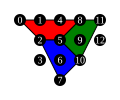

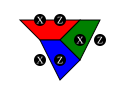

In [3]:
expmt = HexColorCode_Superdense_Memory(
    d=3,
    rounds=3,
    basis="X",
    prep_error_rate=0.001,
    meas_error_rate=0.001,
    gate1_error_rate=0.001,
    gate2_error_rate=0.001,
)
draw_tiles(expmt)

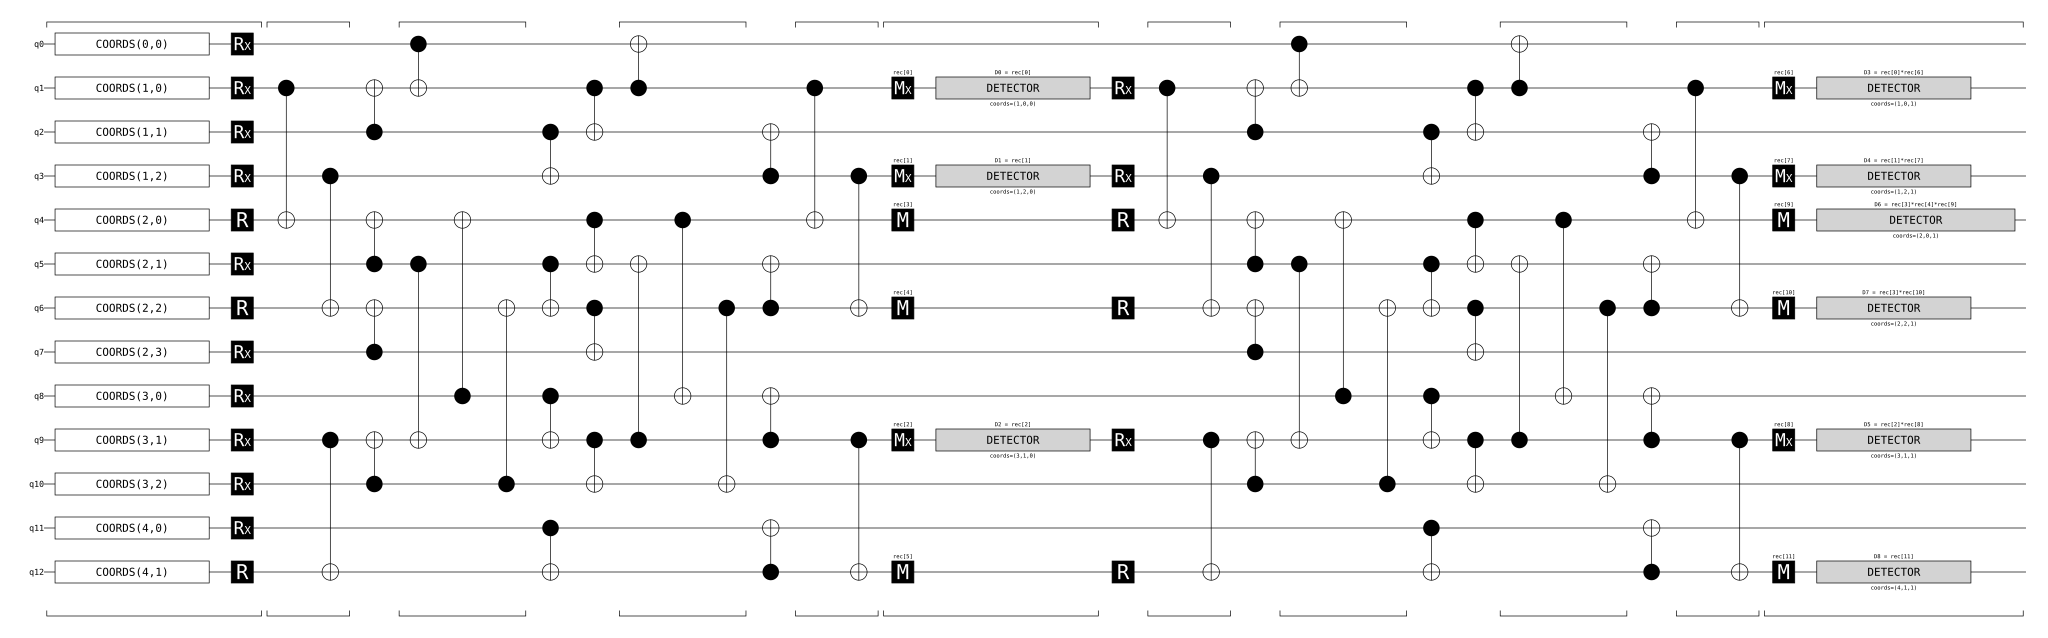

In [4]:
expmt.circuit.diagram("timeline")

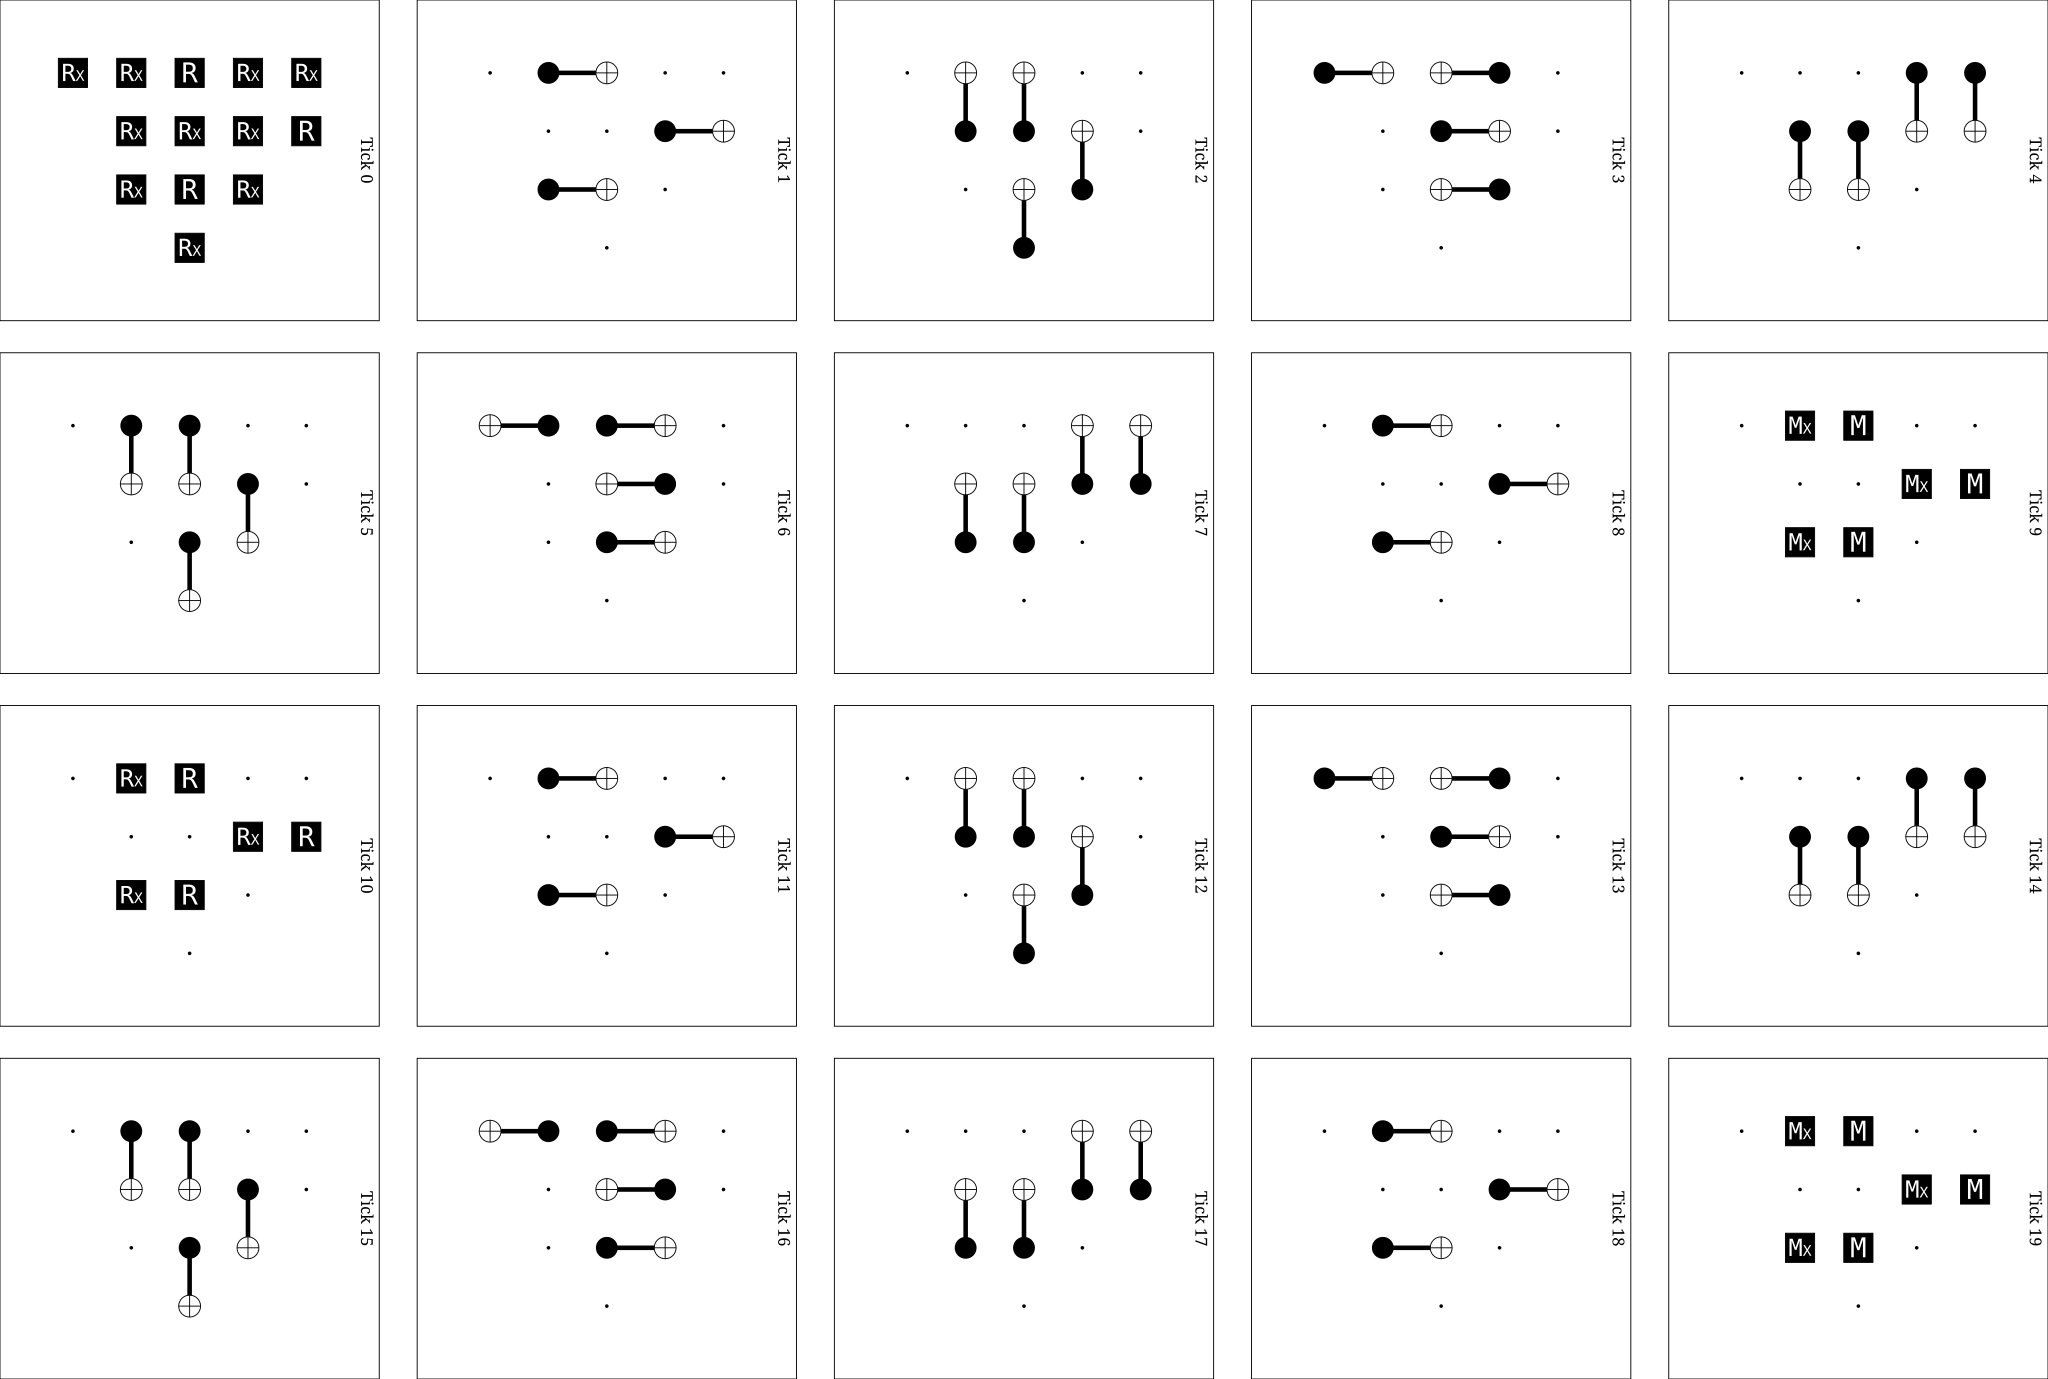

In [5]:
expmt.circuit.diagram("timeslice")